P50 (Median) Overhead : 9.36 µs
P95 Overhead          : 82.86 µs
P99 Overhead          : 265.31 µs


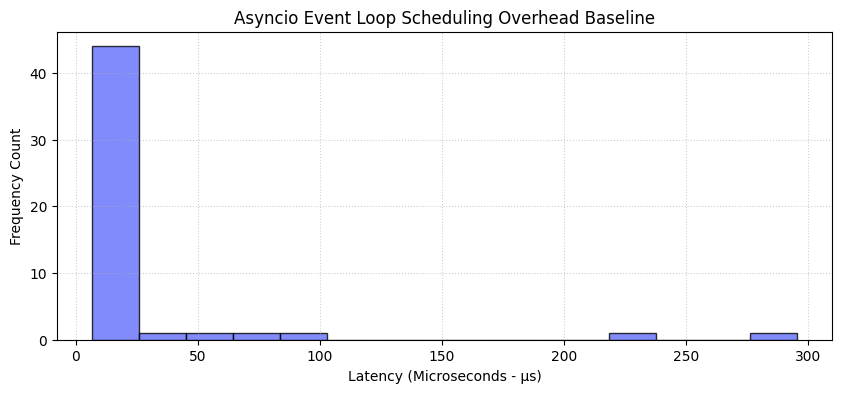

In [ ]:
import asyncio
import time
import matplotlib.pyplot as plt
import numpy as np

async def measure_loop_overhead():
    latencies = []

    # 50 iterations to establish our core baseline
    for _ in range(50):
        t_start = time.perf_counter()

        # Yield control back to the event loop engine
        await asyncio.sleep(0)

        t_end = time.perf_counter()
        latencies.append((t_end - t_start) * 1e6)  # Convert to microseconds (µs)

    return latencies

# Run the coroutine and gather metrics
latencies = await measure_loop_overhead()

# Statistical summary for HRAF reference
print(f"P50 (Median) Overhead : {np.percentile(latencies, 50):.2f} µs")
print(f"P95 Overhead          : {np.percentile(latencies, 95):.2f} µs")
print(f"P99 Overhead          : {np.percentile(latencies, 99):.2f} µs")

# Plot the distribution histogram
plt.figure(figsize=(10, 4))
plt.hist(latencies, bins=15, color='#636EFA', edgecolor='black', alpha=0.8)
plt.title("Asyncio Event Loop Scheduling Overhead Baseline", fontsize=12)
plt.xlabel("Latency (Microseconds - µs)", fontsize=10)
plt.ylabel("Frequency Count", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()